Questions!!

1.2: By accuracy ~0.1 does that just mean costFunction output < 0.1? Or is it 0.99

1.3: Do I need to standarize the weights (non-randomized?) Elsewise am i trying to find empirical average runtime?

In [36]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt


class Neural_Network(object):
    def __init__(self):
        #Define Parameters
        self.inputLayerSize=2
        self.outputLayerSize=1
        self.hiddenLayerSize=3
        
        #Define Weights
        self.W1=np.random.rand(self.inputLayerSize,self.hiddenLayerSize)
        self.W2=np.random.rand(self.hiddenLayerSize,self.outputLayerSize)

    def forward(self,X):
        #Propagate inputs through network
        self.z2 = np.dot(X,self.W1)
        self.a2 = self.sigmoid(self.z2)
        self.z3 = np.dot(self.a2,self.W2)
        yHat = self.sigmoid(self.z3)
        return yHat
    
    def sigmoid(self, z):
        #Apply Sigmoid Activation Function
        return 1/(1+np.exp(-z))
    
    def sigmoidPrime(self,z):
        #Derivative of Sigmoid Function
        return np.exp(-z)/((1+np.exp(-z))**2)
    
    def relu(self, z):
        return np.maximum(0, z)
    
    def reluPrime(self,z):
        return 1 * (z > 0)
    
    def costFunction(self, X, y):
        #Compute Cost Function with weights already stored in class
        self.yHat=self.forward(X)
        J=0.5*sum((y-self.yHat)**2)
        return J
    
    def costFunctionPrime(self, X, y):
        #Compute derivatives with respect to W1 and W2
        self.yHat=self.forward(X)
        delta3 = np.multiply(-(y-self.yHat),self.sigmoidPrime(self.z3))
        dJdW2=np.dot(self.a2.T,delta3)
        delta2=np.dot(delta3,self.W2.T)*self.sigmoidPrime(self.z2)
        dJdW1=np.dot(X.T,delta2)
        return dJdW1,dJdW2
    
    # New attribute functions

    def getW1(self):
        return self.W1  
    
    def setW1(self, new_W1):
        self.W1 = new_W1
    
    def getW2(self):
        return self.W2

    def setW2(self, new_W2):
        self.W2 = new_W2

## 1.1: Schematic Work

In [37]:
X=np.array(([3,5],[5,1],[10,1]),dtype=float)
y=np.array(([75],[80],[93]),dtype=float)

In [38]:
X


array([[ 3.,  5.],
       [ 5.,  1.],
       [10.,  1.]])

In [39]:
y

array([[75.],
       [80.],
       [93.]])

In [40]:
X=X/np.amax(X,axis=0)
y=y/100

In [41]:
X,y


(array([[0.3, 1. ],
        [0.5, 0.2],
        [1. , 0.2]]),
 array([[0.75],
        [0.8 ],
        [0.93]]))

In [42]:
NN=Neural_Network()

In [43]:
yH=NN.forward(X)

In [44]:
yH

array([[0.62079077],
       [0.61992533],
       [0.62903703]])

In [45]:
y

array([[0.75],
       [0.8 ],
       [0.93]])

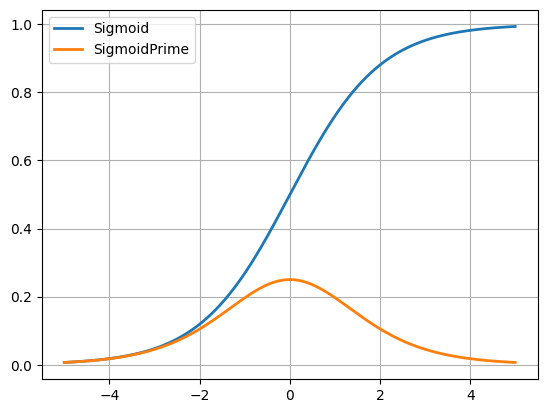

In [46]:
testValues=np.arange(-5,5,0.01)
plt.plot(testValues,NN.sigmoid(testValues),linewidth=2)
plt.plot(testValues, NN.sigmoidPrime(testValues),linewidth=2)
plt.grid(1)
plt.legend(['Sigmoid','SigmoidPrime'])


In [47]:
NN=Neural_Network()

In [48]:
cost1=NN.costFunction(X,y)

In [49]:
cost1

array([0.00891092])

In [50]:
dJdW1,dJdW2=NN.costFunctionPrime(X,y)

In [51]:
dJdW1

array([[-0.00116201, -0.00116432, -0.00134983],
       [ 0.00182359,  0.00137204,  0.00189166]])

In [52]:
dJdW2

array([[0.00168087],
       [0.00241256],
       [0.00183159]])

In [53]:
scalar=1
NN.W1 = NN.W1+scalar*dJdW1
NN.W2 = NN.W2+scalar*dJdW2
cost2 = NN.costFunction(X,y)
print (cost1,cost2)

[0.00891092] [0.00893666]


In [54]:
scalar=0.1
NN.W1 = NN.W1-scalar*dJdW1
NN.W2 = NN.W2-scalar*dJdW2
cost3 = NN.costFunction(X,y)
print (cost2,cost3)

[0.00893666] [0.00893405]


## 1.2: Structure of a Neural Network (50 Points)

### 1.2.1: Minimizing Cost Function w/ Gradient Descent

In [55]:
# Defining Key Variables
acc_threshold = 0.01
alpha = 0.5

X=np.array(([3,5],[5,1],[10,1]),dtype=float)
y=np.array(([75],[80],[93]),dtype=float)

X=X/np.amax(X,axis=0)
y=y/100

In [56]:
my_NN = Neural_Network()

num_iterations_run = 0
cost_list = []

cfa = my_NN.costFunction(X, y) # cost function accuracy
initial_cfa = cfa
cost_list.append(cfa[0])


while cfa > acc_threshold:
    
    if num_iterations_run >= 1000:
        break

    num_iterations_run += 1
    dJdW1,dJdW2 = my_NN.costFunctionPrime(X,y)

    my_NN.setW1(my_NN.getW1() - alpha * dJdW1)
    my_NN.setW2(my_NN.getW2() - alpha * dJdW2)

    cfa = my_NN.costFunction(X, y)
    cost_list.append(cfa[0])

print("Accuracy Threshold: " + str(acc_threshold))
print("Initial CFA: " + str(initial_cfa))
print("Updated CFA: " + str(cfa))
print("Iterations: " + str(num_iterations_run))

Accuracy Threshold: 0.01
Initial CFA: [0.04673433]
Updated CFA: [0.00998939]
Iterations: 39


### 1.2.2: Cost vs. Iteration

Text(0, 0.5, 'Cost Function Accuracy')

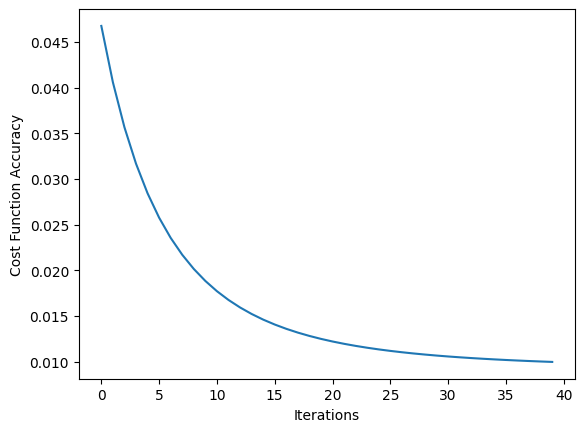

In [57]:
plt.plot(np.arange(0, num_iterations_run + 1), cost_list)
plt.xlabel("Iterations")
plt.ylabel("Cost Function Accuracy")

### 1.2.3: Effects of Large Learing Rate

In [58]:
# changing alpha rate
alpha = 1000

a_NN = Neural_Network()
num_iterations_run = 0
cfa = a_NN.costFunction(X, y) # cost function accuracy
initial_cfa = cfa

while cfa > acc_threshold:
    
    if num_iterations_run >= 1000:
        break

    num_iterations_run += 1
    dJdW1,dJdW2 = a_NN.costFunctionPrime(X,y)

    a_NN.setW1(a_NN.getW1() - alpha * dJdW1)
    a_NN.setW2(a_NN.getW2() - alpha * dJdW2)

    cfa = a_NN.costFunction(X, y)

print("Accuracy Threshold: " + str(acc_threshold))
print("Initial CFA: " + str(initial_cfa))
print("Updated CFA: " + str(cfa))
print("Iterations: " + str(num_iterations_run))

Accuracy Threshold: 0.01
Initial CFA: [0.03592514]
Updated CFA: [0.0537]
Iterations: 1000


Result: Large alpha causes estimate to "jump" over minimum point/accuracy threshold

### 1.2.4: Forward Pass

In [59]:
y_hat = my_NN.forward(X)
print(y)
print(y_hat)

[[0.75]
 [0.8 ]
 [0.93]]
[[0.82782456]
 [0.79342683]
 [0.81219121]]


## 1.3: ReLU vs. Sigmoid Activation

### 1.3.1: Relu vs. Sigmoid Comparison

In [60]:
class ReLu_Network(Neural_Network):
    def forward(self,X):
        #Propagate inputs through network
        self.z2 = np.dot(X,self.W1)
        self.a2 = self.relu(self.z2) # changed to relu function
        self.z3 = np.dot(self.a2,self.W2)
        yHat = self.sigmoid(self.z3)
        return yHat

ReLu Network

Relu Stats 
---
Accuracy Threshold: 0.01
Initial CFA: [0.05294274]
Updated CFA: [0.00929385]
Iterations: 12
Actual: [[0.75]
 [0.8 ]
 [0.93]]
Predicted: [[0.76569051]
 [0.70606212]
 [0.83244396]]


Text(0, 0.5, 'Cost Function Accuracy')

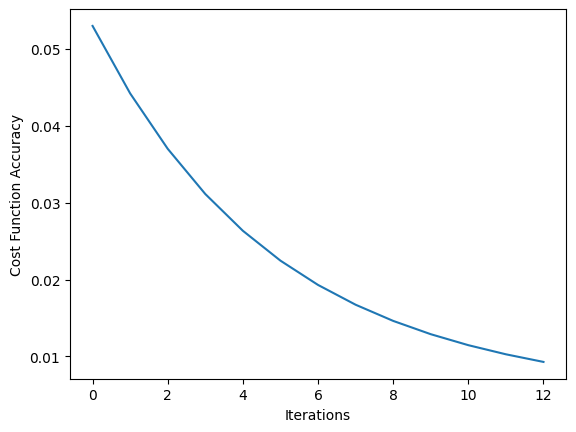

In [68]:
relu_NN = ReLu_Network()

alpha = 1
iterations_relu = 0
cfa_relu = []

cfa = relu_NN.costFunction(X, y) # cost function accuracy
initial_cfa = cfa
cfa_relu.append(cfa[0])

while cfa > acc_threshold:
    
    if iterations_relu >= 1000:
        break

    iterations_relu += 1
    dJdW1,dJdW2 = relu_NN.costFunctionPrime(X,y)

    relu_NN.setW1(relu_NN.getW1() - alpha * dJdW1)
    relu_NN.setW2(relu_NN.getW2() - alpha * dJdW2)

    cfa = relu_NN.costFunction(X, y)
    cfa_relu.append(cfa[0])

print("Relu Stats \n---")
print("Accuracy Threshold: " + str(acc_threshold))
print("Initial CFA: " + str(initial_cfa))
print("Updated CFA: " + str(cfa))
print("Iterations: " + str(iterations_relu))

y_hat = relu_NN.forward(X)
print("Actual: " + str(y))
print("Predicted: " + str(y_hat))

plt.plot(np.arange(0, iterations_relu + 1), cfa_relu)
plt.xlabel("Iterations")
plt.ylabel("Cost Function Accuracy")


Sigmoid Network

Sigmoid Stats 
---
Accuracy Threshold: 0.01
Initial CFA: [0.03500959]
Updated CFA: [0.00990897]
Iterations: 17
Actual: [[0.75]
 [0.8 ]
 [0.93]]
Predicted: [[0.8291688 ]
 [0.79158252]
 [0.81389926]]


Text(0, 0.5, 'Cost Function Accuracy')

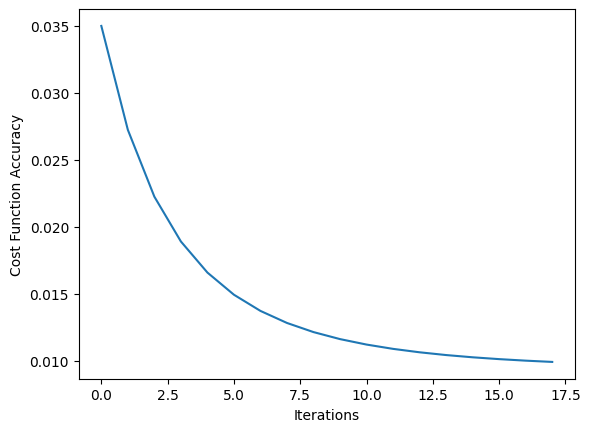

In [62]:
sigmoid_NN = Neural_Network()

alpha = 1
iterations_sigmoid = 0
cfa_sigmoid = []

cfa = sigmoid_NN.costFunction(X, y) # cost function accuracy
initial_cfa = cfa
cfa_sigmoid.append(cfa[0])

while cfa > acc_threshold:
    
    if iterations_sigmoid >= 1000:
        break

    iterations_sigmoid += 1
    dJdW1,dJdW2 = sigmoid_NN.costFunctionPrime(X,y)

    sigmoid_NN.setW1(sigmoid_NN.getW1() - alpha * dJdW1)
    sigmoid_NN.setW2(sigmoid_NN.getW2() - alpha * dJdW2)

    cfa = sigmoid_NN.costFunction(X, y)
    cfa_sigmoid.append(cfa[0])

print("Sigmoid Stats \n---")
print("Accuracy Threshold: " + str(acc_threshold))
print("Initial CFA: " + str(initial_cfa))
print("Updated CFA: " + str(cfa))
print("Iterations: " + str(iterations_sigmoid))

y_hat = sigmoid_NN.forward(X)
print("Actual: " + str(y))
print("Predicted: " + str(y_hat))

plt.plot(np.arange(0, iterations_sigmoid + 1), cfa_sigmoid)
plt.xlabel("Iterations")
plt.ylabel("Cost Function Accuracy")

### 1.3.2: 3 Unit Hidden Layer & 10 Unit Hidden Layer

In [63]:
class NN_2Layer(Neural_Network):
    def __init__(self, h2_size):
        #Define Parameters
        self.inputLayerSize=2
        self.hiddenLayer1Size=3
        self.hiddenLayer2Size = h2_size
        self.outputLayerSize=1
        
        #Define Weights
        self.W1=np.random.rand(self.inputLayerSize,self.hiddenLayer1Size)
        self.W2=np.random.rand(self.hiddenLayer1Size,self.hiddenLayer2Size)
        self.W3=np.random.rand(self.hiddenLayer2Size,self.outputLayerSize)
    
    def forward(self, X):
        # Input to Hidden 1
        self.z2 = np.dot(X, self.W1)
        self.a2 = self.relu(self.z2)
        
        # Hidden 1 to Hidden 2
        self.z3 = np.dot(self.a2, self.W2)
        self.a3 = self.relu(self.z3)
        
        # Hidden 2 to Output
        self.z4 = np.dot(self.a3, self.W3)
        yHat = self.sigmoid(self.z4) 
        
        return yHat
    
    def costFunctionPrime(self, X, y):
        self.yHat = self.forward(X)
        
        # Output Layer Error (using sigmoid derivative)
        delta4 = np.multiply(-(y - self.yHat), self.sigmoidPrime(self.z4))
        dJdW3 = np.dot(self.a3.T, delta4)
        
        # Hidden Layer 2 Error (using ReLU derivative)
        delta3 = np.dot(delta4, self.W3.T) * self.reluPrime(self.z3)
        dJdW2 = np.dot(self.a2.T, delta3)
        
        # Hidden Layer 1 Error (using ReLU derivative)
        delta2 = np.dot(delta3, self.W2.T) * self.reluPrime(self.z2)
        dJdW1 = np.dot(X.T, delta2)
        
        return dJdW1, dJdW2, dJdW3
    
    def getW3(self):
        return self.W3

    def setW3(self, new_W3):
        self.W3 = new_W3

3 Unit Hidden Layer

3 Unit Layer Stats 
---
Accuracy Threshold: 0.01
Initial CFA: [0.06403294]
Updated CFA: [0.00961302]
Iterations: 6
Actual: [[0.75]
 [0.8 ]
 [0.93]]
Predicted: [[0.83836178]
 [0.72876314]
 [0.85035363]]


Text(0, 0.5, 'Cost Function Accuracy')

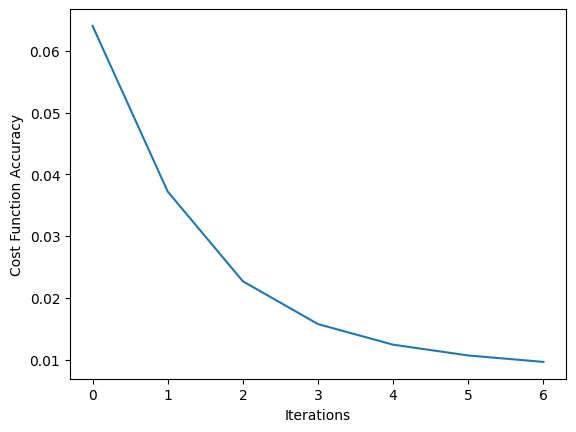

In [72]:
NN_3 = NN_2Layer(3)

alpha = 1
iterations_NN3 = 0
cfa_NN3 = []

cfa = NN_3.costFunction(X, y) # cost function accuracy
initial_cfa = cfa
cfa_NN3.append(cfa[0])

while cfa > acc_threshold:
    
    if iterations_NN3 >= 1000:
        break

    iterations_NN3 += 1
    dJdW1,dJdW2, dJdW3 = NN_3.costFunctionPrime(X,y)

    NN_3.setW1(NN_3.getW1() - alpha * dJdW1)
    NN_3.setW2(NN_3.getW2() - alpha * dJdW2)
    NN_3.setW3(NN_3.getW3() - alpha * dJdW3)

    cfa = NN_3.costFunction(X, y)
    cfa_NN3.append(cfa[0])

print("3 Unit Layer Stats \n---")
print("Accuracy Threshold: " + str(acc_threshold))
print("Initial CFA: " + str(initial_cfa))
print("Updated CFA: " + str(cfa))
print("Iterations: " + str(iterations_NN3))

y_hat = NN_3.forward(X)
print("Actual: " + str(y))
print("Predicted: " + str(y_hat))

plt.plot(np.arange(0, iterations_NN3 + 1), cfa_NN3)
plt.xlabel("Iterations")
plt.ylabel("Cost Function Accuracy")


10 Unit Hidden Layer

10 Unit Layer Stats 
---
Accuracy Threshold: 0.01
Initial CFA: [0.03271179]
Updated CFA: [0.0082476]
Iterations: 27
Actual: [[0.75]
 [0.8 ]
 [0.93]]
Predicted: [[0.86351597]
 [0.75995627]
 [0.88521366]]


Text(0, 0.5, 'Cost Function Accuracy')

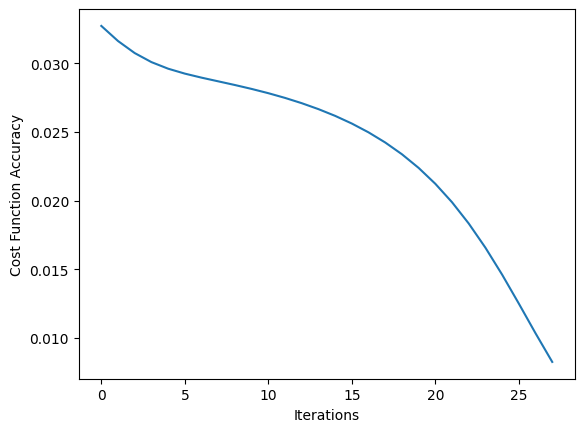

In [71]:
NN_10 = NN_2Layer(10)

alpha = 1
iterations_NN10 = 0
cfa_NN10 = []

cfa = NN_10.costFunction(X, y) # cost function accuracy
initial_cfa = cfa
cfa_NN10.append(cfa[0])

while cfa > acc_threshold:
    
    if iterations_NN10 >= 1000:
        break

    iterations_NN10 += 1
    dJdW1,dJdW2, dJdW3 = NN_10.costFunctionPrime(X,y)

    NN_10.setW1(NN_10.getW1() - alpha * dJdW1)
    NN_10.setW2(NN_10.getW2() - alpha * dJdW2)
    NN_10.setW3(NN_10.getW3() - alpha * dJdW3)

    cfa = NN_10.costFunction(X, y)
    cfa_NN10.append(cfa[0])

print("10 Unit Layer Stats \n---")
print("Accuracy Threshold: " + str(acc_threshold))
print("Initial CFA: " + str(initial_cfa))
print("Updated CFA: " + str(cfa))
print("Iterations: " + str(iterations_NN10))

y_hat = NN_10.forward(X)
print("Actual: " + str(y))
print("Predicted: " + str(y_hat))

plt.plot(np.arange(0, iterations_NN10 + 1), cfa_NN10)
plt.xlabel("Iterations")
plt.ylabel("Cost Function Accuracy")

Comparison of all Neural Networks

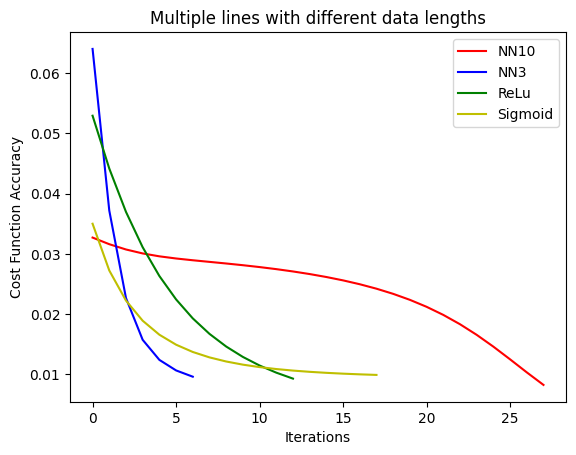

In [77]:
#x_axis = np.arange(0, max([iterations_NN10, iterations_NN3, iterations_relu, iterations_sigmoid]) + 1)

# Create a single figure and axes
fig, ax = plt.subplots()

# Plot the first line
ax.plot(np.arange(0, iterations_NN10 + 1), cfa_NN10, label='NN10', color='r')
ax.plot(np.arange(0, iterations_NN3 + 1), cfa_NN3, label='NN3', color='b')
ax.plot(np.arange(0, iterations_relu + 1), cfa_relu, label='ReLu', color='g')
ax.plot(np.arange(0, iterations_sigmoid + 1), cfa_sigmoid, label='Sigmoid', color='y')

# Add labels, title, and legend
ax.set_xlabel('Iterations')
ax.set_ylabel('Cost Function Accuracy')
ax.set_title('Multiple lines with different data lengths')
ax.legend()